<a href="https://colab.research.google.com/github/hieuvu-0111/Machine_Learning_Linear_Regression/blob/main/Machine_Learning_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear regression {-}

This notebook is adapted from a Machine Learning course assignment aiming to familiarize students with the use of Linear Regression model supported by scikit-learn. Particularly:

1.  **Coding Tasks:**

    1.1 Analyze the dataset using libraries like Pandas and Matplotlib.  
    1.2 Preprocess the data for modeling.  
    1.3 Divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.  
    1.4 Train a Linear Regression model on the training set.    
    1.5 Evaluate the model performance on the test set.  

2.  **Open discussion questions:**

    2.1 Does income or income stability have a stronger influence on the loan sanction amount? For example, analyze the data to see if a higher income or a "High" income stability rating leads to a greater loan approval amount.  
    2.2 Is there a significant difference in loan amounts based on property location? For example, compare the average loan amounts for properties in rural, urban, and semi-urban locations.  
    2.3 Is there a gender bias in loan approvals? For example, investigate if there is a difference in average loan amounts offered to male and female applicants.  
    2.4 Are there any new features you could create from the existing data (e.g., loan-to-value ratio) that might be useful for analyzing loan amounts?  
    2.5 Beyond loan amount prediction, what other insights can be extracted or predicted from this dataset? For example, explore possibilities of using the data to understand borrower behavior, property market trends, or develop targeted marketing strategies.  


The dataset you will be working on is 'house-loan.csv'. It is composed of attributes such as gender, age, income, etc. This dataset is to predict the loan amount for which a customer can request a bank with his/her collateral house.



In [ ]:
import numpy as np
import pandas as pd

This is a dataset about loan amount for which a customer can request a bank with his/her collateral house.

* Gender: Gender of customer requesting for a loan ('F' or 'M').
* Age: Age of customer requesting for a loan (non-negative values).
* Income (USD): Income of customer requesting for a loan (non-negative values).
* Income Stability: Income stability of customer requesting for a loan ("Low" or "High").
* Property Age: Age of the property (non-negative number of days).
* Property Location: Location of the property ("Rural", "Urban", and "Semi-Urban").
* Property Price: Price of the property (USD).
* Loan Sanction Amount (USD): Amount of loan the customer can request for (USD, target value).

In [ ]:
# Load and display data
data = pd.read_csv("house_loan.csv")
data.head()

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,F,19,1641.25,Low,1651.25,Rural,59641.82,21026.420753
1,M,29,1989.71,Low,1990.71,Urban,179858.51,60595.183366
2,F,37,1849.91,Low,1856.91,Rural,117297.62,39181.648002
3,M,65,2735.18,High,2747.18,Rural,354417.72,128497.710865
4,F,62,4741.78,High,4740.78,Urban,82049.80,39386.919336


## 1. Coding tasks

### 1.1 *(1 point)* Analyze the dataset using libraries like Pandas and Matplotlib.  

In [ ]:
# Check for data types
data.dtypes

,0
Gender,object
Age,int64
Income (USD),float64
Income Stability,object
Property Age,float64
Property Location,object
Property Price,float64
Loan Sanction Amount (USD),float64


As we can see, this dataset includes both numerical and categorical datatypes. Because linear regression model only works with numerical variables, these categorical data features (gender, income stability, property location) will be converted into numerical datatypes.

In [ ]:
data.describe(include = "all")

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
count,47297,47297.000000,47265.000000,47285,47263.000000,47294,4.729700e+04,47297.000000
unique,2,NaN,NaN,2,NaN,3,NaN,NaN
top,F,NaN,NaN,Low,NaN,Semi-Urban,NaN,NaN
freq,23669,NaN,NaN,43078,NaN,16371,NaN,NaN
mean,NaN,40.000063,2586.684384,NaN,2586.611058,NaN,1.350880e+05,46487.229765
std,NaN,16.086128,1558.768809,NaN,1558.842286,NaN,9.457875e+04,32549.905634
min,NaN,18.000000,372.700000,NaN,370.700000,NaN,7.859620e+03,254.586578
25%,NaN,24.000000,1653.740000,NaN,1652.820000,NaN,6.250408e+04,21782.822159
50%,NaN,40.000000,2245.480000,NaN,2244.810000,NaN,1.130936e+05,38822.132402
75%,NaN,55.000000,3128.560000,NaN,3128.380000,NaN,1.819546e+05,62612.236905


By using ``describe()`` function, we can see the statistics of all data features in this dataset. For example, the average income is 2586.68 USD.

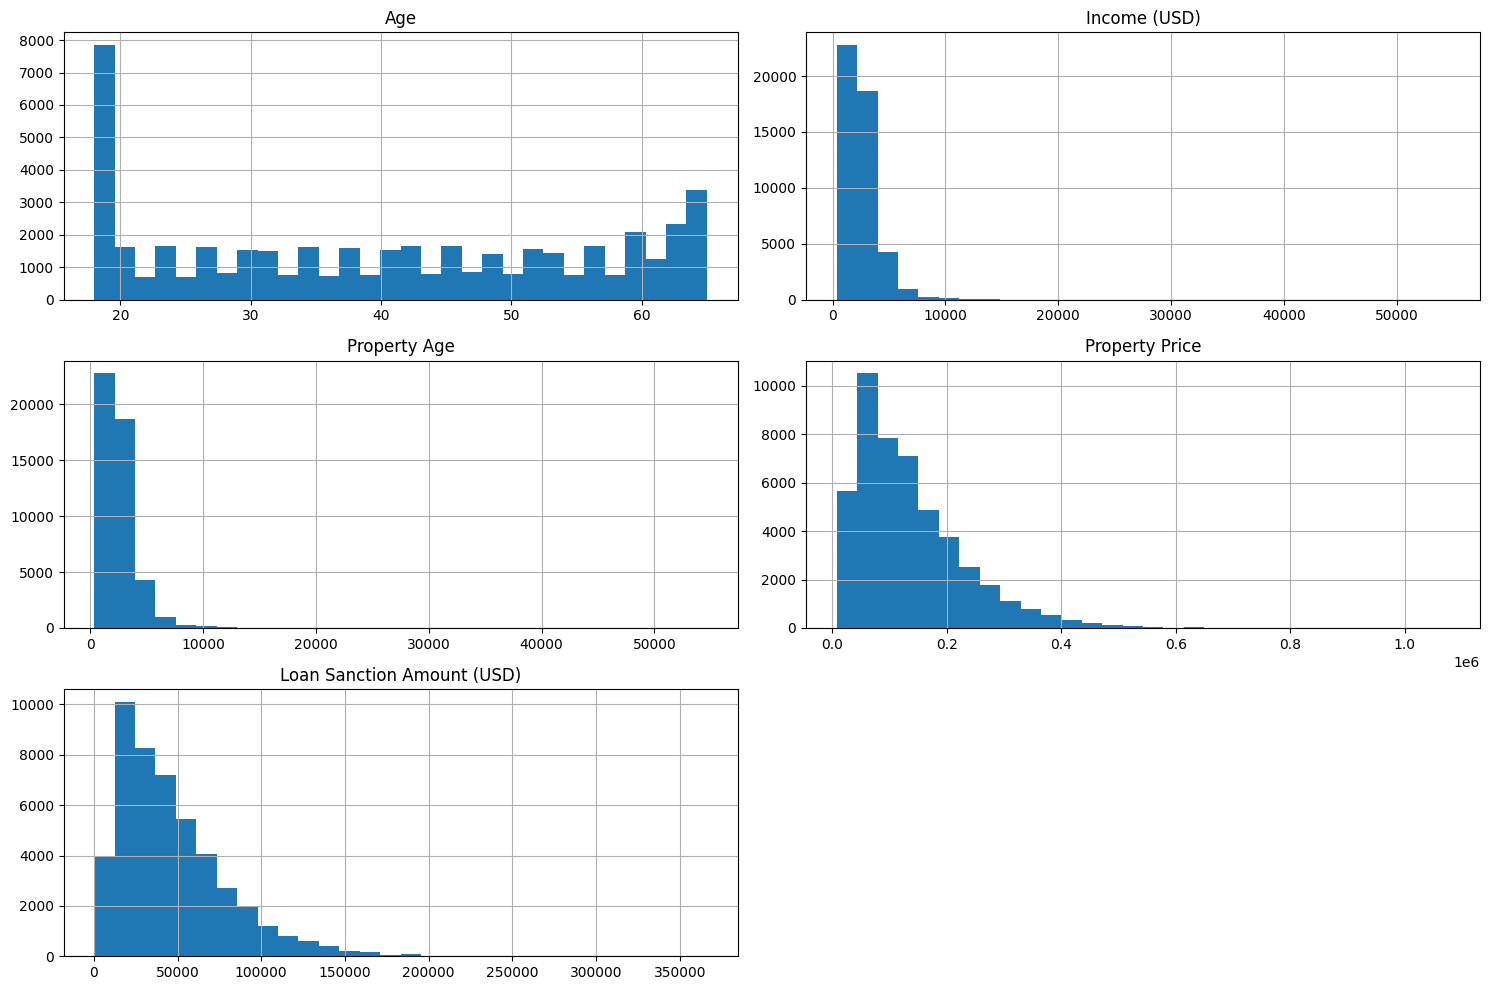

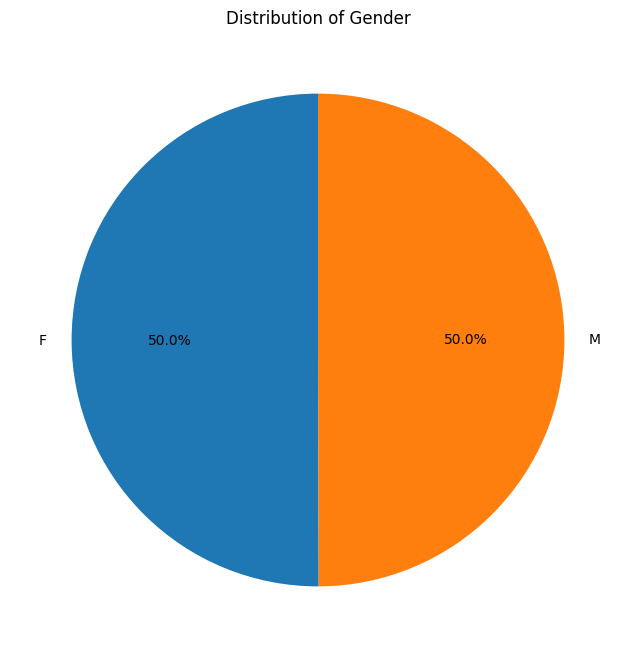

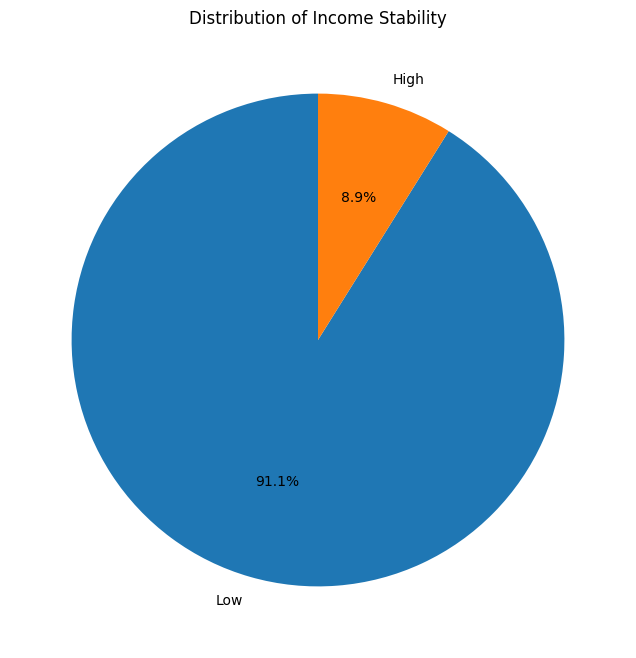

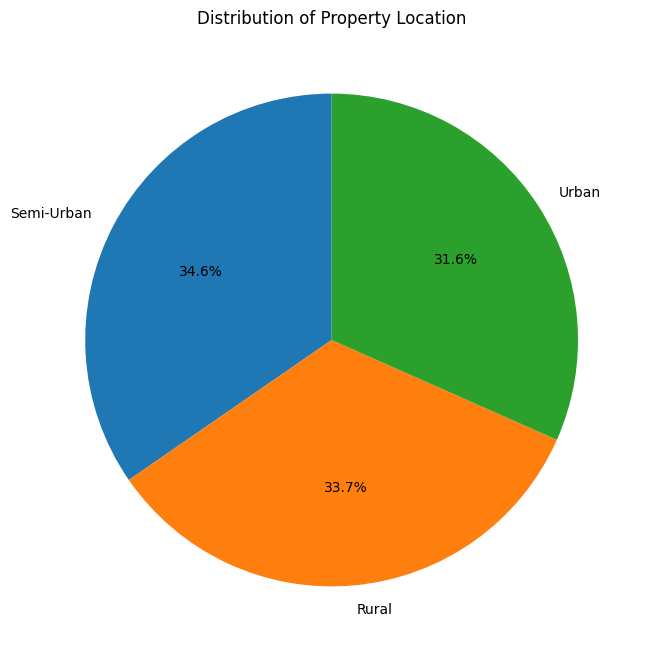

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of numerical features using histograms
numerical_features = data.select_dtypes(include=np.number).columns
data[numerical_features].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Visualize the distribution of categorical features using pie charts
categorical_features_pie = ['Gender', 'Income Stability', 'Property Location']
for col in categorical_features_pie:
    plt.figure(figsize=(8, 8))
    data[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {col}')
    plt.ylabel('')
    plt.show()

By using ``MathplotLib`` library, we can visualize the distribution of data features in the dataset.

Based on the histograms, we can obtain some following insights:

- Age: In this dataset, age distributes highly skewed toward younger ages (around 20 years old) and older age (60+), so the dataset may include many young applicants and a significant number of older individuals, possibly retirees.
- Income: The income distribution is right-skewed, with most individuals have income below \$10,000, and very few earning above \$10,000. This pattern aligns with real-world income distributions, where high-income individuals are relatively rare.
- Property age: The property age distribution is right-skewed, with the majority of properties are relatively new. It suggest that most properties in the datase are recently built, but there still exist properties with ages over 1000.
- Property price: The distribution of property price is also right-skewed, with most of them are priced below \$200,000, and a long tail extending up to \$1,000,000. It implies that a small number of high-value property significantly increase the range.
- Loan sanction amount: It has dright-skewed distribution. Most loans are under \$50,000, with a few very large loans exceeding \$150,000.

Overall, the distributions of age, income, property age, property price, and loan sanction amount are consistent with typical real-world patterns and provide a realistic dataset for modeling.

About the pie charts:
- Gender: The dataset contains an equal number of male and female applicants, so there is no gender bias.
- Income stability: The “Low” stability category dominates, which is reasonable and reflects real-world income variability.
- Property location: The proportions of urban, semi-urban, and rural regions are relatively balanced, so it is fair across locations.

Overall, the dataset appears balanced and realistic, with feature distributions that mirror real-world trends. This makes it suitable for developing a linear regression model and further predictive analysis.

### 1.2 *(1 point)* Preprocess the data for modeling.  
    

From part 1.1, we know that the dataset contains some categorical data features while linear regression can only work with numerical values. Therefore, I encode these categorical values into numbers by using one-hot encoding.

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# List of categorical columns
categorical_cols = ['Gender', 'Income Stability', 'Property Location']

# Use pandas get_dummies
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Ensure encoded columns are numeric
data_encoded = data_encoded.astype(float)

# Display the encoded dataset
data_encoded.head()


,Age,Income (USD),Property Age,Property Price,Loan Sanction Amount (USD),Gender_M,Income Stability_Low,Property Location_Semi-Urban,Property Location_Urban
0,19.0,1641.25,1651.25,59641.82,21026.420753,0.0,1.0,0.0,0.0
1,29.0,1989.71,1990.71,179858.51,60595.183366,1.0,1.0,0.0,1.0
2,37.0,1849.91,1856.91,117297.62,39181.648002,0.0,1.0,0.0,0.0
3,65.0,2735.18,2747.18,354417.72,128497.710865,1.0,0.0,0.0,0.0
4,62.0,4741.78,4740.78,82049.80,39386.919336,0.0,0.0,0.0,1.0


In [ ]:
# Remove rows with missing values
data_encoded = data_encoded.dropna()

In [ ]:
# Pre-process data, determine feature x and label y
columns = data_encoded.columns.tolist()                          # Get column names.
columns.remove('Loan Sanction Amount (USD)')                     # Remove 'Loan Sanction Amount (USD)' (label y column)
feature_data = data_encoded[columns]                             # Assign a variable to features x, including all columns except 'Loan Sanction Amount (USD)'
target_data = data_encoded['Loan Sanction Amount (USD)']         # Assign 'Loan Sanction Amount (USD)' to label y

### 1.3 *(1 point)* Divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.  
    

In [ ]:
from sklearn.model_selection import train_test_split
trainX,testX, trainY,testY = train_test_split(feature_data, target_data, train_size=0.80)     # Split the data into two subsets for training and testing.
print('Training:' + str(trainX.shape))                                                        # Count data samples in Training set.
print('Test:' + str(testX.shape))                                                             # Count data samples in Test set.

Training:(37810, 8)
Test:(9453, 8)


### 1.4 *(1 point)* Train a Linear Regression model on the training set.    
    


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Initialize a StandardScaler and a Linear Regression model, then create a pipeline
model = make_pipeline(StandardScaler(), LinearRegression())

In [ ]:
model.fit(trainX,trainY)                                # Learn Linear Regression using (x, y) pairs in the Training set.
# Access the LinearRegression model from the pipeline to get the intercept and coefficients
linear_regression_model = model.named_steps['linearregression']
print("Model intercept: " + str(linear_regression_model.intercept_))      # Observe the bias (theta_0) parameter.
print("Model coefficients: " + str(linear_regression_model.coef_))        # Observe 8 coefficients corresponding to 8 features x after learning.

Model intercept: 46511.7976200253
Model coefficients: [-1275.62475029   784.63590033   810.21823612 31809.41475631
  -123.93949013 -3180.61602296  -130.23511813   -55.41935541]


 ### 1.5 *(1 point)* Evaluate the model performance on the test set.

In [ ]:
testX[:8]     # Observe 8 features x of the first 8 samples in the Test set.

,Age,Income (USD),Property Age,Property Price,Gender_M,Income Stability_Low,Property Location_Semi-Urban,Property Location_Urban
13800,44.0,1647.23,1637.23,33120.18,0.0,1.0,0.0,1.0
39428,62.0,4525.02,4520.02,332773.98,0.0,1.0,1.0,0.0
24230,18.0,3011.90,3001.90,130704.90,1.0,1.0,0.0,0.0
3694,63.0,1660.62,1651.62,21355.18,1.0,1.0,1.0,0.0
43161,47.0,1279.04,1266.04,64949.87,0.0,1.0,0.0,1.0
32777,19.0,1627.07,1629.07,357606.69,1.0,1.0,0.0,0.0
6983,18.0,3952.39,3955.39,165844.90,1.0,1.0,1.0,0.0
24415,24.0,1742.03,1741.03,318594.89,0.0,1.0,1.0,0.0


In [ ]:
testY[:8]     # Observe labels y of the first 8 samples in the Test set.

,Loan Sanction Amount (USD)
13800,9997.856218
39428,112038.760054
24230,46131.521887
3694,4182.868968
43161,20074.499228
32777,120861.613708
6983,58628.100969
24415,107438.137187


In [ ]:
model.predict(testX[:8])     # Make prediction on the first 8 samples in the Test set.

array([ 10042.88612418, 112185.1313331 ,  46196.61739016,   4190.55401239,
        20127.31867342, 120996.42264742,  58713.70733908, 107572.31069595])

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

pred = model.predict(testX)                                              # Make prediction on the whole Test set.
mae = mean_absolute_error(y_pred=pred, y_true=testY)                           # Calculate mean absolute error to observe the performance of the learned model based on the predictions and the labels.

# Calculate Mean Absolute Percentage Error (MAPE)
# Avoid division by zero by adding a small epsilon to the true values
mape = np.mean(np.abs((testY - pred) / (testY + 1e-8))) * 100

print(f"Mean Absolute Error: {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error: 112.88572313140693
Mean Absolute Percentage Error (MAPE): 0.27%


A mean absolute percentage error of 0.28% is quite low. It implies that, on average, the model's predictions for the loan sanction amount are off by only 0.28% from the actual values. This suggests that the linear regression model has learned the underlying patterns in the data very well and is making highly accurate predictions on the test set. It indicates a very good quality model for this specific dataset and target variable.

## 2. Open discussion questions

From the linear regression model, we can obtain some following interpretations:



### Feature Coefficients

\
\begin{array}{lrr}
\textbf{Feature} & \textbf{Coefficient} & \textbf{Interpretation} \\
\hline
\text{Age} & −1,275.62 & \text{Older applicants may receive lower loan amounts (ceteris paribus).} \\
\text{Income (USD)} & +784.63 & \text{Higher income increases the loan amount.} \\
\text{Property Age} & +810.21 & \text{Older properties slightly increase loan amount.} \\
\text{Property Price} & +31,809.41 & \text{By far the largest effect — higher property prices strongly raise loan amount.} \\
\text{Gender_M} & −123.93 & \text{Male applicants tend to get slightly lower loans, but negligible.} \\
\text{Income Stability_Low} & −3,180.61 & \text{Applicants with low income stability receive 3,151 less — significant negative effect.} \\
\text{Property Location_Semi-Urban} & −130.23 & \text{Slightly lower loans in semi-urban areas.} \\
\text{Property Location_Urban} & −55.41 & \text{Very small negative effect.} \\
\end{array}

### Linear Regression Model Equation

The linear regression model equation with the calculated coefficients is:

$\text{Loan Sanction Amount (USD)} = \text{Intercept}
+ (\beta_1 \times \text{Age})
+ (\beta_2 \times \text{Income (USD)})
+ (\beta_3 \times \text{Property Age})
+ (\beta_4 \times \text{Property Price})
+ (\beta_5 \times \text{Gender_M})
+ (\beta_6 \times \text{Income Stability_Low})
+ (\beta_7 \times \text{Property Location_Semi-Urban})
+ (\beta_8 \times \text{Property Location_Urban})$


Using the coefficients calculated in part 1:


\begin{aligned}
\text{Loan Sanction Amount (USD)}
&= 46,511.79
+ (-1,275.62 \times \text{Age}) \\
&\quad
+ (784.63 \times \text{Income (USD)})
+ (810.21 \times \text{Property Age}) \\
&\quad
+ (31,809.41 \times \text{Property Price})
+ (-123.93 \times \text{Gender_M}) \\
&\quad
+ (-3,180.61 \times \text{Income Stability_Low})
+ (-130.23 \times \text{Property Location_Semi-Urban}) \\
&\quad  
+ (-55.41 \times \text{Property Location_Urban})
\end{aligned}




 ### 2.1 *(1 point)* Does income or income stability have a stronger influence on the loan sanction amount? For example, analyze the data to see if a higher income or a "High" income stability rating leads to a greater loan approval amount.  
    

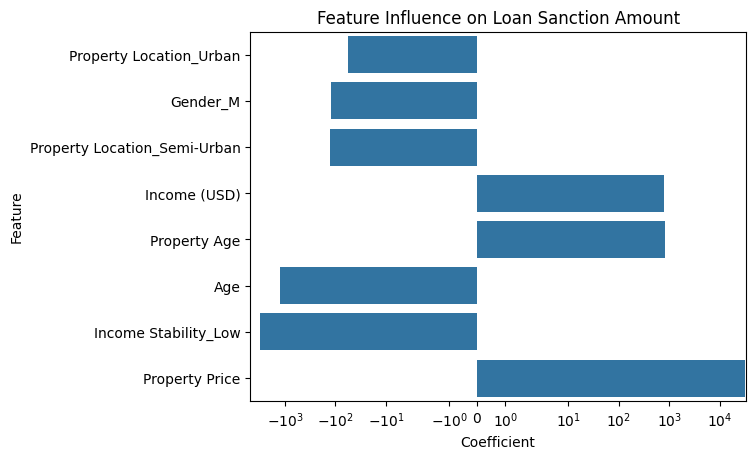

In [ ]:
coef_df = pd.DataFrame({
    'Feature': ['Age', 'Income (USD)', 'Property Age', 'Property Price',
                'Gender_M', 'Income Stability_Low',
                'Property Location_Semi-Urban', 'Property Location_Urban'],
    'Coefficient': [-1275.62475029,   784.63590033,   810.21823612, 31809.4147563,
                    -123.93949013, -3180.61602296,  -130.23511813,   -55.41935541]
}).sort_values('Coefficient', key=abs, ascending=True)

sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Feature Influence on Loan Sanction Amount')
plt.xscale('symlog')            # Use symmetric logarithmic scale for better visualization of small values
plt.show()

Based on the linear regression results, both income and income stability are significant predictors of the sanctioned loan amount.

The coefficient for Income (USD) is +784.63, i.e., higher income leads to an increase in loan amount.

The coefficient for Low Income Stability is −3,180.61, suggesting that applicants with low stability receive, on average, loans about $3,184.04 smaller than those with stable income profiles.

This demonstrates that **income stability has a stronger overall effect on the loan sanction decision compared to income itself.**

The following boxplots confirm that stability status plays a significant role in loan approval decisions.

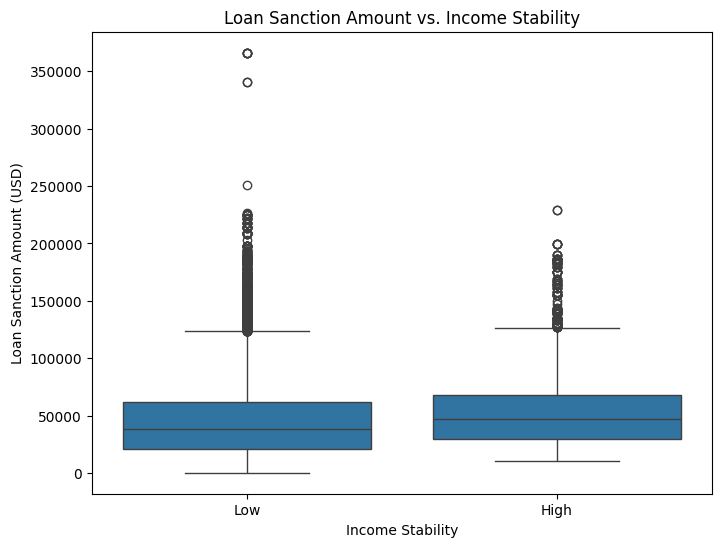

Average Loan Sanction Amount by Income Stability:
  Income Stability  Loan Sanction Amount (USD)
0             High                53860.177837
1              Low                45766.887972


In [ ]:
# Visualize the relationship between Income Stability and Loan Sanction Amount (USD) using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Income Stability', y='Loan Sanction Amount (USD)', data=data)
plt.title('Loan Sanction Amount vs. Income Stability')
plt.xlabel('Income Stability')
plt.ylabel('Loan Sanction Amount (USD)')
plt.show()

# Calculate the average loan sanction amount for each income stability level
average_loan_by_stability = data.groupby('Income Stability')['Loan Sanction Amount (USD)'].mean().reset_index()
print("Average Loan Sanction Amount by Income Stability:")
print(average_loan_by_stability)

Based on the box plot and the average loan sanction amounts, there appears to be a difference in loan amounts based on income stability. The box plot shows that the median and overall distribution of loan sanction amounts are higher for individuals with 'High' income stability compared to those with 'Low' income stability. The calculated averages also confirm that the average loan amount for the 'High' income stability group is greater than that for the 'Low' income stability group. This suggests that income stability does have an influence on the loan sanction amount.

### 2.2 *(1 point)* Is there a significant difference in loan amounts based on property location? For example, compare the average loan amounts for properties in rural, urban, and semi-urban locations.  
  

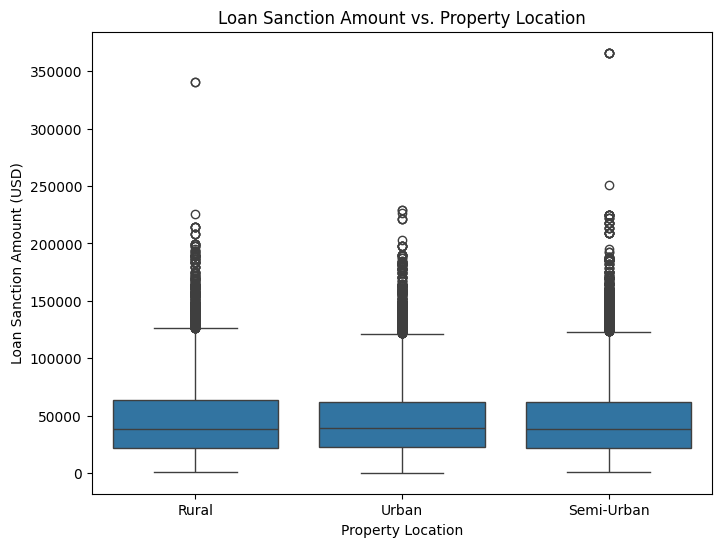

Average Loan Sanction Amount by Property Location:
  Property Location  Loan Sanction Amount (USD)
0             Rural                46637.898995
1        Semi-Urban                46330.675163
2             Urban                46498.496942


In [ ]:
# Analyze the influence of property location on loan sanction amount

# Visualize the relationship between Property Location and Loan Sanction Amount (USD) using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Property Location', y='Loan Sanction Amount (USD)', data=data)
plt.title('Loan Sanction Amount vs. Property Location')
plt.xlabel('Property Location')
plt.ylabel('Loan Sanction Amount (USD)')
plt.show()

# Calculate the average loan sanction amount for each property location
average_loan_by_location = data.groupby('Property Location')['Loan Sanction Amount (USD)'].mean().reset_index()
print("Average Loan Sanction Amount by Property Location:")
print(average_loan_by_location)

Based on the box plot and the average loan sanction amounts by property location, it appears that there is no significant difference in average loan amounts across rural, urban, and semi-urban areas. The average loan amounts are quite similar for all three locations. The box plot also shows similar distributions of loan amounts for each location category.

 ### 2.3 *(1 point)* Is there a gender bias in loan approvals? For example, investigate if there is a difference in average loan amounts offered to male and female applicants.  
  

Average Loan Sanction Amount by Gender:
  Gender  Loan Sanction Amount (USD)
0      F                46373.629432
1      M                46601.027222


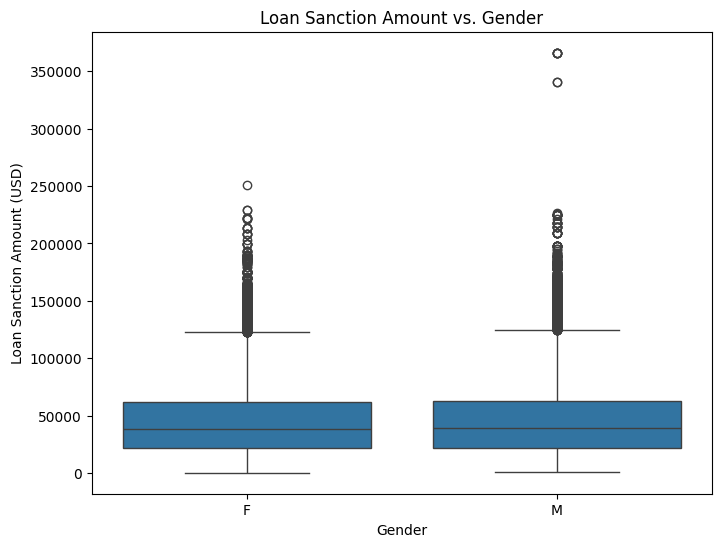

In [ ]:
# Analyze gender bias in loan approvals

# Calculate the average loan sanction amount for each gender
average_loan_by_gender = data.groupby('Gender')['Loan Sanction Amount (USD)'].mean().reset_index()
print("Average Loan Sanction Amount by Gender:")
print(average_loan_by_gender)

# Visualize the distribution of loan sanction amount by gender using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Loan Sanction Amount (USD)', data=data)
plt.title('Loan Sanction Amount vs. Gender')
plt.xlabel('Gender')
plt.ylabel('Loan Sanction Amount (USD)')
plt.show()

Based on the analysis of the average loan sanction amounts by gender and the box plot, there is not a significant gender bias in loan approvals in this dataset. The average loan amounts for male and female applicants are very close (male's amount is slightly greater than female's amount), and the distributions in the box plot are similar.

Also, this is an interesting situation when average loan amounts of male are greater than female, while the coefficient of linear regression model suggests that being male may slightly decrease loan amounts. However, it turns out that these two indexes are not the same. The average value is a simple comparison of group means and does not control for any other variable, while the regression coefficient measures effect of gender after controlling for all other predictors (income, property price, stability, etc.). If a male and a female have the same income, property price, stability, etc., the male’s predicted loan is $129 lower. In this case, it is very possible that males in the dataset tend to have higher incomes or more expensive properties, which increase loan amounts and thus so do the mean value.

  ### 2.4 *(1 point)* Are there any new features you could create from the existing data (e.g., loan-to-value ratio) that might be useful for analyzing loan amounts?  
    

From the dataset, we can derive two new features to further understand the determinants of loan amounts, which are the Loan-to-Value (LTV) ratio and the Loan-to-Income (LTI) ratio.

$LTV = \dfrac{\text{Loan amounts}}{\text{Property Price}}$

$LTI = \dfrac{\text{Loan amounts}}{\text{Income}}$.


The LTV ratio reflects how much of the property’s value is financed by the loan, and the LTI ratio measures the borrower’s repayment burden relative to income. High LTV means that borrower contributes less equity, so it is riskier for lender. High LTI means that borrower takes a large loan relative to income, so it may create a repayment stress. Both ratios help explain not only the loan amount but also the approval likelihood or loan policy patterns.

In [ ]:
# Create ratios
data['LTV_Ratio'] = data['Loan Sanction Amount (USD)'] / data['Property Price']
data['LTI_Ratio'] = data['Loan Sanction Amount (USD)'] / data['Income (USD)']

# Quick check
data[['Income (USD)', 'Property Price', 'Loan Sanction Amount (USD)', 'LTV_Ratio', 'LTI_Ratio']].head()


,Income (USD),Property Price,Loan Sanction Amount (USD),LTV_Ratio,LTI_Ratio
0,1641.25,59641.82,21026.420753,0.352545,12.811224
1,1989.71,179858.51,60595.183366,0.336905,30.454279
2,1849.91,117297.62,39181.648002,0.334036,21.180300
3,2735.18,354417.72,128497.710865,0.362560,46.979618
4,4741.78,82049.80,39386.919336,0.480037,8.306357


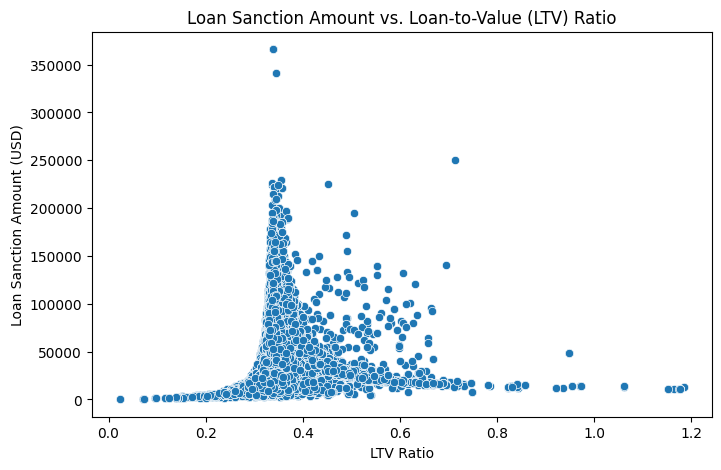

In [ ]:
# Visualize the relationship of loan amount vs loan-to-value
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x='LTV_Ratio', y='Loan Sanction Amount (USD)', data=data)
plt.title('Loan Sanction Amount vs. Loan-to-Value (LTV) Ratio')
plt.xlabel('LTV Ratio')
plt.ylabel('Loan Sanction Amount (USD)')
plt.show()


As we can see, most data points are concentrated around an LTV ratio of 0.3–0.4, where loan amounts range from \$0 to about $150,000. This indicates that lenders typically approve loans when the loan amount is roughly 30–40% of the property value. There is a sharp peak in density at this range, suggesting it is the most common lending practice. Beyond an LTV ratio of 0.6, the number of loans drops significantly, and very few loans exist above 0.8, implying that lenders rarely approve loans that approach or exceed the property value. Very high LTVs (low-value properties with full financing) may correspond to smaller loan amounts.

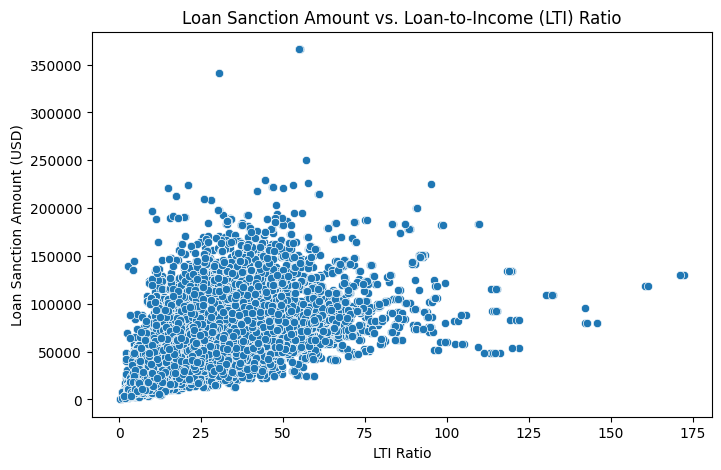

In [ ]:
# Visualize the relationship of loan amount vs loan-to-income
plt.figure(figsize=(8,5))
sns.scatterplot(x='LTI_Ratio', y='Loan Sanction Amount (USD)', data=data)
plt.title('Loan Sanction Amount vs. Loan-to-Income (LTI) Ratio')
plt.xlabel('LTI Ratio')
plt.ylabel('Loan Sanction Amount (USD)')
plt.show()


Based on the plot, most data points are concentrated in the lower LTI range (0–60) with loan amounts between \$0 and $150,000, which means that the majority of borrowers have relatively low LTI ratios and moderate loan sizes. There is a general upward trend where higher LTI ratios correspond to larger loan amounts, but this pattern weakens beyond an LTI ratio of about 50.

Overall, the plot implies that lenders typically cap loan amounts even when LTI ratios are high, and most lending activity occurs within a conservative LTI range.

An interesting fact derived from 2 plots is that the scale of LTI ratio is much higher than that of LTV. While LTV ratio is typically between 0 and 1, LTI ratio can exceed 50 and even more.

LTV is bounded because property value and loan amount are closely linked, i.e., lenders rarely allow loans greater than the property value.

LTI is unbounded because income varies widely and does not directly cap the loan amount. In this case, high LTI ratios indicate borrowers taking loans far beyond their income capacity, which may signal higher credit risk.

### 2.5 *(1 point)* Beyond loan amount prediction, what other insights can be extracted or predicted from this dataset? For example, explore possibilities of using the data to understand borrower behavior, property market trends, or develop targeted marketing strategies.  

Beyond predicting the loan sanction amount, this dataset can be used to gain other valuable insights.

In terms of analyzing borrower behavior, we could segment borrowers based on demographics (Gender, Age), income characteristics (Income, Income Stability), and property attributes (Property Age, Property Location, Property Price) to understand different borrower profiles and their borrowing patterns. For example, do males borrow more than females, do individuals with higher income stability borrow more than ones with lower income stability?

To analyze the property market trends, we could build a model to predict property prices based on features like property age, property location, and potential borrower characteristics. Also, we can further analyze property prices and loan amounts across different locations to identify potential trends or disparities in the property market.

Moreover, by analyzing the characteristics of borrowers, we can understand the needs and profiles of different borrower groups, then it can help in tailoring loan products and marketing strategies to specific groups.


As an example, we will build a linear regression model to predict the property prices based on other features like property age and property location.

In [ ]:
# Pre-process data, determine feature x and label y
columns = data_encoded.columns.tolist()               # Get column names.
columns.remove('Property Price')                      # Remove 'Property Price' (label y column)
feature_data = data_encoded[columns]                  # Assign a variable to features x, including all columns except 'Property Price'
target_data = data_encoded['Property Price']          # Assign 'Property Price' to label y

In [ ]:
from sklearn.model_selection import train_test_split
trainX,testX, trainY,testY = train_test_split(feature_data, target_data, train_size=0.80)     # Split the data into two subsets for training and testing.
print('Training:' + str(trainX.shape))                                                        # Count data samples in Training set.
print('Test:' + str(testX.shape))                                                             # Count data samples in Test set.

Training:(37810, 8)
Test:(9453, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Initialize a StandardScaler and a Linear Regression model, then create a pipeline
model = make_pipeline(StandardScaler(), LinearRegression())

In [ ]:
model.fit(trainX,trainY)                                # Learn Linear Regression using (x, y) pairs in the Training set.
# Access the LinearRegression model from the pipeline to get the intercept and coefficients
linear_regression_model = model.named_steps['linearregression']
print("Model intercept: " + str(linear_regression_model.intercept_))      # Observe the bias (theta_0) parameter.
print("Model coefficients: " + str(linear_regression_model.coef_))        # Observe 8 coefficients corresponding to 8 features x after learning.

Model intercept: 135275.3685683681
Model coefficients: [ 3779.51193328 -2353.34560322 -2395.85682283 96826.7786013
   395.70460329  9468.70990548   351.62251329   137.59360655]


In [ ]:
testX[:8]     # Observe 8 features x of the first 8 samples in the Test set.

,Age,Income (USD),Property Age,Loan Sanction Amount (USD),Gender_M,Income Stability_Low,Property Location_Semi-Urban,Property Location_Urban
37381,35.0,4150.97,4149.97,35869.682673,0.0,1.0,0.0,1.0
31604,18.0,1870.78,1860.78,12121.012730,0.0,1.0,0.0,0.0
46481,63.0,948.73,947.73,16162.994791,0.0,0.0,0.0,1.0
9154,31.0,2331.31,2342.31,21785.009123,1.0,1.0,0.0,0.0
25692,27.0,1843.04,1850.04,63206.459257,1.0,1.0,0.0,0.0
11060,64.0,874.34,875.34,14298.544683,0.0,1.0,0.0,1.0
26998,33.0,3010.09,3009.09,14971.272830,1.0,1.0,0.0,1.0
12953,63.0,3028.48,3031.48,27802.592857,1.0,1.0,1.0,0.0


In [ ]:
testY[:8]     # Observe labels y of the first 8 samples in the Test set.

,Property Price
37381,100384.95
31604,32226.95
46481,24694.88
9154,63327.40
25692,187188.13
11060,52969.10
26998,41876.53
12953,87488.14


In [ ]:
model.predict(testX[:8])     # Make prediction on the first 8 samples in the Test set.

array([100277.3718789 ,  32343.17438493,  24847.62666091,  63457.05315844,
       186930.52837157,  52853.68382748,  41984.67565719,  87486.41060105])

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

pred = model.predict(testX)                                              # Make prediction on the whole Test set.
mae = mean_absolute_error(y_pred=pred, y_true=testY)                           # Calculate mean absolute error to observe the performance of the learned model based on the predictions and the labels.

# Calculate Mean Absolute Percentage Error (MAPE)
# Avoid division by zero by adding a small epsilon to the true values
mape = np.mean(np.abs((testY - pred) / (testY + 1e-8))) * 100

print(f"Mean Absolute Error: {mae}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error: 472.3920854804637
Mean Absolute Percentage Error (MAPE): 0.36%


A MAPE of 0.34% for the property price prediction model is quite low. Similar to the previous model, this indicates that, on average, the model's predictions for property price are only off by 0.34% from the actual values. This suggests that the linear regression model is performing very well in predicting property prices based on the features used.

From the model, we can obtain some following insights:

- Property price is significantly determined by loan size, which means that the financial product (loan amount) is tightly aligned with property valuation.

- Property age shows normal depreciation trends. The older the property is, the cheaper it is.

- Income stability surprisingly shows a positive effect. The result could indicate that applicants with lower stability buy more expensive properties through higher borrowing, or even it is due to sample bias.

- Income, gender, and location are weak predictors. It suggests that market pricing is relatively uniform across demographics and regions in the dataset.